# Tutorial 5: Calculating LCOE (`module_lcoe`)
This tutorial explains how to retrieve tidal data, load rotor performance data, simulate rotor dynamics, check constraints, and calculate the Levelized Cost of Energy (LCOE). Follow the steps below to process and analyze turbine and vessel performance.

1. **Retrieve Tidal Data**  
   Retrieve tidal data using the `process_tidal_data` function. This provides flow speeds, time steps, and mooring distance for the simulation.

Mooring Distance (m): 43.3
Buoy Latitude (rad): 1.0626780980630117
Buoy Longitude (rad): -2.639508202614978
Station Name: Middle Ground Shoal, E of.
Nearest City: Anchorage
Cable Length (m): 80705.88


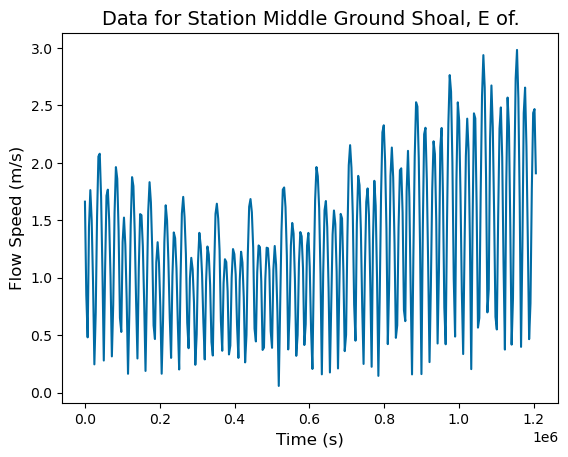

In [1]:
# Import necessary modules
from vital.module_tidal import process_tidal_data
import matplotlib.pyplot as plt

import urllib3

# Suppress InsecureRequestWarning
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# Define parameters for tidal data retrieval
station = "COI1210"  # NOAA station identifier
startdate = "2020-01-01"  # Start date for tidal data retrieval

# Retrieve tidal data
tidal = process_tidal_data(station=station, startdate=startdate)

# Print tidal data attributes
print(f"Mooring Distance (m): {tidal.mooring_distance}")
print(f"Buoy Latitude (rad): {tidal.latitude}")
print(f"Buoy Longitude (rad): {tidal.longitude}")
print(f"Station Name: {tidal.station_name}")
print(f"Nearest City: {tidal.nearest_city}")
print(f"Cable Length (m): {tidal.cable_length}")

# Plot flow speeds over time
plt.figure()
plt.plot(tidal.times, tidal.flow_speeds)
plt.xlabel("Time (s)", fontsize=12)
plt.ylabel("Flow Speed (m/s)", fontsize=12)
plt.title(f"Data for Station {tidal.station_name}", fontsize=14)
plt.show()

2. **Load Rotor Data**  
   Load rotor performance data using the `RotorData` class. This provides Cp, Ct, and Cq functions for the simulation.

In [2]:
from vital.module_rotor import RotorData

# Define rotor performance file
RotorPerformanceFile = "../data/Sitkana_rotor_data_blade_2.txt"

# Load rotor data
rotor = RotorData(RotorPerformanceFile)

# Print optimal Cp and TSR values
print(f"Optimal Cp: {rotor.CpOpt}")
print(f"Optimal TSR: {rotor.TSROpt}")

Optimal Cp: 0.21189
Optimal TSR: 0.76477


3. **Simulate Rotor Dynamics**  
   Set up simulation parameters and run the rotor simulation using the `RotorSimulation` class.

In [3]:
from vital.module_rotor_simulation import RotorSimulation
import numpy as np

# Define simulation parameters
config = {
    'Radius': 1.5,  # Rotor radius
    'Prated': 10000.0,  # Rated power
    'Trated': np.inf,  # Rated torque
    'dHub': 3.0,  # Hub depth
    'number_of_turbines': 2,  # Number of turbines
    'dMoor': tidal.mooring_distance,  # Mooring distance from tidal data
    'Uinf': tidal.flow_speeds,  # Flow speeds from tidal data
    't': tidal.times,  # Time steps from tidal data
    'CpFunc': rotor.get_cp,  # Cp function from rotor data
    'CqFunc': rotor.get_cq,  # Cq function from rotor data
    'CtFunc': rotor.get_ct,  # Ct function from rotor data
    'CpOpt': rotor.CpOpt,  # Optimal Cp from rotor data
    'TSROpt': rotor.TSROpt,  # Optimal TSR from rotor data
    'TSRmax': rotor.TSRmax,  # Maximum TSR from rotor data
    'Ng': 50,  # Gear ratio
    'Kt': 2,  # Generator torque constant
    'Rw': 0.5,  # Rotor resistance
    'J_d': 1,  # Drivetrain inertia
    'B_d': 1,  # Drivetrain damping coefficient
    'J_r': 10,  # Rotor inertia
}

# Simulate rotor dynamics
rotor_sim = RotorSimulation(config)
rotor_sim.simulate()
result = rotor_sim.get_results()

Solving the initial value problem (IVP) for turbine dynamics...
IVP solving complete.


4. **Define Vessel Properties**  
   Define vessel properties and initialize the `VesselData` object.

In [4]:
from vital.module_vessel import VesselData

# Define user vessel properties
user_vessel_properties = {
    'Xm': 5.77,  # Horizontal distance from center of rotation
    'Zm': 1.65,  # Vertical distance from center of rotation
    'Kphi': 1.95e6,  # Pitch hydrostatic stiffness
    'theta': 45.0 * np.pi / 180.0,  # Mooring line angle in radians
    'phi': 20.0 * np.pi / 180.0,  # Vessel pitch angle in radians
    'area': 9.5,  # Cross-sectional area of the vessel
    'Cd': 1.0,  # Drag coefficient
}

# Initialize VesselData object
vessel = VesselData(
    user_defined=True,
    vessel_properties=user_vessel_properties,
    simResult=result
)

5. **Check Constraints**  
   Use the `ConstraintChecker` class to check power, depth, cavitation, and pitch constraints.

In [5]:
from vital.module_constraint_checker import ConstraintChecker

# Initialize ConstraintChecker object
constraint_checker = ConstraintChecker(rotor, config, vessel, result)

# Check constraints
power_constraint_satisfied = constraint_checker.check_power_constraint()
depth_constraint_satisfied = constraint_checker.check_depth_constraint()
cavitation_constraint_satisfied = constraint_checker.check_cavitation_constraint()
pitch_constraint_satisfied = constraint_checker.check_pitch_constraint()

# Print constraint results
if power_constraint_satisfied:
    print('Power constraint satisfied')
if depth_constraint_satisfied:
    print('Depth constraint satisfied')
if cavitation_constraint_satisfied:
    print('Cavitation constraint satisfied')
if pitch_constraint_satisfied:
    print('Pitch constraint satisfied')

Power constraint satisfied
Depth constraint satisfied
Cavitation constraint satisfied
Pitch constraint satisfied


6. **Calculate LCOE**  
   Define LCOE parameters and calculate the Levelized Cost of Energy using the `LCOECalculator` class.

In [6]:
from vital.module_lcoe import LCOEData, LCOECalculator

# Define LCOE parameters
my_turbinelifetime = 10  # Turbine lifetime in years
my_discount_rate = 0.1  # Discount rate
my_turbulence_intensity = 0.0  # Turbulence intensity
my_batteryCapacity = 10.0  # Battery capacity in kWh

# Initialize LCOE classes
data = LCOEData(
    tidal, config, vessel, result,
    my_turbinelifetime, my_discount_rate,
    my_turbulence_intensity,
    customer='customer_B',
    application='battery_charging',
    BatteryCapacity_kWh=my_batteryCapacity
)
calculator = LCOECalculator(data)

# Perform LCOE calculations
lcoe = calculator.calculate_lcoe()
print(f"LCOE: {lcoe}")

# List annual energy production
calculator.list_annual_energy()

# Calculate and list CAPEX
total_capex = calculator.calculate_total_capex()
calculator.list_capex()

# List OPEX components
calculator.list_opex(total_capex)

LCOE: 3.002522135320453
Annual Energy Generation: 23208.57 kWh
CAPEX Components:
  anchor_cost: $442.63
  gearbox_cost: $926.86
  concrete_cost: $106.02
  assembly_cost: $1014.00
  generator_cost: $4084.00
  rotor_cost: $42.39
  steel_component_cost: $914.66
  rotor_construction_cost: $19.65
  battery_cost: $1500.00
  charge_controller_cost: $2096.60
Total CAPEX: $11146.82
OPEX Components:
  SITKANA Operating Cost: $67870.14
Total OPEX: $67870.14
